In [2]:
import zipfile
import os

# Define the path to the zip file and the extraction directory
zip_file_path = '/content/archive.zip'
extract_dir = '/content/unzipped_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}' successfully.")
print("Contents of the unzipped directory:")
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

'/content/archive.zip' unzipped to '/content/unzipped_data' successfully.
Contents of the unzipped directory:
unzipped_data/
    car details v4.csv
    CAR DETAILS FROM CAR DEKHO.csv
    car data.csv
    Car details v3.csv


# Task
Load the `car details v4.csv` file into a pandas DataFrame and display its head, information, and descriptive statistics.

## Explore Data

### Subtask:
Load one of the car details CSV files, such as 'car details v4.csv', into a pandas DataFrame and display its head, info, and descriptive statistics to understand the dataset structure, column types, and identify potential features and target variables.


**Reasoning**:
To load the 'car details v4.csv' file into a pandas DataFrame and display its head, info, and descriptive statistics, I will import pandas, construct the file path, read the CSV, and then use the `.head()`, `.info()`, and `.describe()` methods.



In [3]:
import pandas as pd

# Construct the full file path for 'car details v4.csv'
file_path = os.path.join(extract_dir, 'car details v4.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

print("DataFrame Head:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDataFrame Descriptive Statistics:")
print(df.describe())

DataFrame Head:
            Make                            Model    Price  Year  Kilometer  \
0          Honda              Amaze 1.2 VX i-VTEC   505000  2017      87150   
1  Maruti Suzuki                  Swift DZire VDI   450000  2014      75000   
2        Hyundai             i10 Magna 1.2 Kappa2   220000  2011      67000   
3         Toyota                         Glanza G   799000  2019      37500   
4         Toyota  Innova 2.4 VX 7 STR [2016-2020]  1950000  2018      69000   

  Fuel Type Transmission   Location   Color   Owner Seller Type   Engine  \
0    Petrol       Manual       Pune    Grey   First   Corporate  1198 cc   
1    Diesel       Manual   Ludhiana   White  Second  Individual  1248 cc   
2    Petrol       Manual    Lucknow  Maroon   First  Individual  1197 cc   
3    Petrol       Manual  Mangalore     Red   First  Individual  1197 cc   
4    Diesel       Manual     Mumbai    Grey   First  Individual  2393 cc   

            Max Power              Max Torque Drivet

## Preprocess Data

### Subtask:
Clean and preprocess the selected dataset, including handling missing values and converting relevant columns to appropriate data types.


**Reasoning**:
The subtask requires calculating missing values, extracting numerical data from specific columns ('Engine', 'Max Power', 'Max Torque'), converting them to numeric types, and then imputing missing values using medians or mode, followed by displaying the updated DataFrame's information and descriptive statistics for verification. All these steps are related to data preprocessing and can be performed in a single code block.



In [4]:
print("Percentage of missing values per column:")
print((df.isnull().sum() / len(df)) * 100)

# 2. Extract numerical part from 'Engine' column and convert to numeric
# The regex extracts numbers, including decimals, for various formats like '1198 cc' or '2393 cc'
df['Engine_CC'] = df['Engine'].str.extract('([0-9.]+)', expand=False).astype(float)
median_engine_cc = df['Engine_CC'].median()
df['Engine_CC'].fillna(median_engine_cc, inplace=True)

# 3. Extract numerical part from 'Max Power' column and convert to numeric
# The regex extracts numbers, including decimals, for various formats like '87 bhp @ 6000 rpm'
df['Max_Power_BHP'] = df['Max Power'].str.extract('([0-9.]+)', expand=False).astype(float)
median_max_power_bhp = df['Max_Power_BHP'].median()
df['Max_Power_BHP'].fillna(median_max_power_bhp, inplace=True)

# 4. Extract numerical part from 'Max Torque' column and convert to numeric
# The regex extracts numbers, including decimals, for various formats like '109 Nm @ 4500 rpm' or '112.7619 Nm @ 4000 rpm'
df['Max_Torque_NM'] = df['Max Torque'].str.extract('([0-9.]+)', expand=False).astype(float)
median_max_torque_nm = df['Max_Torque_NM'].median()
df['Max_Torque_NM'].fillna(median_max_torque_nm, inplace=True)

# 5. Impute missing values in numerical columns with their respective medians
numerical_cols_to_impute = ['Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']
for col in numerical_cols_to_impute:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# 6. Impute missing values in the 'Drivetrain' column with its mode
if df['Drivetrain'].isnull().any():
    mode_drivetrain = df['Drivetrain'].mode()[0]
    df['Drivetrain'].fillna(mode_drivetrain, inplace=True)

print("\nDataFrame Info after preprocessing:")
df.info()

print("\nDataFrame Descriptive Statistics after preprocessing:")
print(df.describe())

Percentage of missing values per column:
Make                  0.000000
Model                 0.000000
Price                 0.000000
Year                  0.000000
Kilometer             0.000000
Fuel Type             0.000000
Transmission          0.000000
Location              0.000000
Color                 0.000000
Owner                 0.000000
Seller Type           0.000000
Engine                3.885381
Max Power             3.885381
Max Torque            3.885381
Drivetrain            6.605148
Length                3.108305
Width                 3.108305
Height                3.108305
Seating Capacity      3.108305
Fuel Tank Capacity    5.488101
dtype: float64

DataFrame Info after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non

/tmp/ipykernel_683/647207352.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Engine_CC'].fillna(median_engine_cc, inplace=True)
/tmp/ipykernel_683/647207352.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

**Reasoning**:
The previous code produced `FutureWarning` messages due to the use of `inplace=True` with chained assignments. To resolve this, I will modify the `.fillna()` calls to directly reassign the result back to the DataFrame column, which is the recommended approach in newer pandas versions.



In [5]:
print("Percentage of missing values per column:")
print((df.isnull().sum() / len(df)) * 100)

# 2. Extract numerical part from 'Engine' column and convert to numeric
# The regex extracts numbers, including decimals, for various formats like '1198 cc' or '2393 cc'
df['Engine_CC'] = df['Engine'].str.extract('([0-9.]+)', expand=False).astype(float)
median_engine_cc = df['Engine_CC'].median()
df['Engine_CC'] = df['Engine_CC'].fillna(median_engine_cc)

# 3. Extract numerical part from 'Max Power' column and convert to numeric
# The regex extracts numbers, including decimals, for various formats like '87 bhp @ 6000 rpm'
df['Max_Power_BHP'] = df['Max Power'].str.extract('([0-9.]+)', expand=False).astype(float)
median_max_power_bhp = df['Max_Power_BHP'].median()
df['Max_Power_BHP'] = df['Max_Power_BHP'].fillna(median_max_power_bhp)

# 4. Extract numerical part from 'Max Torque' column and convert to numeric
# The regex extracts numbers, including decimals, for various formats like '109 Nm @ 4500 rpm' or '112.7619 Nm @ 4000 rpm'
df['Max_Torque_NM'] = df['Max Torque'].str.extract('([0-9.]+)', expand=False).astype(float)
median_max_torque_nm = df['Max_Torque_NM'].median()
df['Max_Torque_NM'] = df['Max_Torque_NM'].fillna(median_max_torque_nm)

# 5. Impute missing values in numerical columns with their respective medians
numerical_cols_to_impute = ['Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']
for col in numerical_cols_to_impute:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# 6. Impute missing values in the 'Drivetrain' column with its mode
if df['Drivetrain'].isnull().any():
    mode_drivetrain = df['Drivetrain'].mode()[0]
    df['Drivetrain'] = df['Drivetrain'].fillna(mode_drivetrain)

print("\nDataFrame Info after preprocessing:")
df.info()

print("\nDataFrame Descriptive Statistics after preprocessing:")
print(df.describe())

Percentage of missing values per column:
Make                  0.000000
Model                 0.000000
Price                 0.000000
Year                  0.000000
Kilometer             0.000000
Fuel Type             0.000000
Transmission          0.000000
Location              0.000000
Color                 0.000000
Owner                 0.000000
Seller Type           0.000000
Engine                3.885381
Max Power             3.885381
Max Torque            3.885381
Drivetrain            0.000000
Length                0.000000
Width                 0.000000
Height                0.000000
Seating Capacity      0.000000
Fuel Tank Capacity    0.000000
Engine_CC             0.000000
Max_Power_BHP         0.000000
Max_Torque_NM         0.000000
dtype: float64

DataFrame Info after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              -------------

## Train Model

### Subtask:
Select and train an appropriate machine learning model (e.g., a regression model for car price prediction or a classification model) using the preprocessed training data.


**Reasoning**:
To prepare the data for model training, I will first define the feature matrix X and target vector y, then identify and one-hot encode the categorical features, split the data into training and testing sets, and finally train a RandomForestRegressor model.



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. Define feature matrix X and target vector y
y = df['Price']
X = df.drop(columns=['Price', 'Engine', 'Max Power', 'Max Torque', 'Model'])

print("Shape of X before encoding:", X.shape)

# 2. Identify categorical features in X
categorical_features = X.select_dtypes(include=['object']).columns

# 3. Apply one-hot encoding to identified categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print("Shape of X after one-hot encoding:", X.shape)

# 4. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split into training and testing sets. X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# 5. Import and instantiate the RandomForestRegressor model
model = RandomForestRegressor(random_state=42)

# 6. Train the RandomForestRegressor model
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

Shape of X before encoding: (2059, 18)
Shape of X after one-hot encoding: (2059, 152)
Data split into training and testing sets. X_train shape: (1647, 152), X_test shape: (412, 152)
RandomForestRegressor model trained successfully.


## Evaluate Model

### Subtask:
Evaluate the performance of the trained model on the test dataset using relevant metrics (e.g., R-squared, MAE, MSE for regression, or accuracy, precision, recall, F1-score for classification).


**Reasoning**:
To evaluate the trained RandomForestRegressor model, I will use `mean_absolute_error`, `mean_squared_error`, and `r2_score` from `sklearn.metrics` to calculate the MAE, MSE, and R-squared values from the model's predictions on the test set and then print these metrics.



In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 295066.81
Mean Squared Error (MSE): 1215888518092.92
R-squared (R2) Score: 0.83


## Convert Model to ONNX

### Subtask:
Convert the trained machine learning model into the ONNX format, which is suitable for deployment in various environments, including web applications.


**Reasoning**:
To convert the trained `RandomForestRegressor` model to ONNX format, I need to import the `convert_sklearn` function and `onnx` library, define the input type based on `X_train.shape[1]`, then use `convert_sklearn` to perform the conversion, and finally save the resulting ONNX model to a file.



In [8]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx

# 1. Define the initial data types for the input features
# X_train.shape[1] gives the number of features in the training data
initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]

# 2. Convert the trained model into ONNX format
# The model is a RandomForestRegressor, which is a scikit-learn model
onnx_model = convert_sklearn(model, initial_types=initial_type)

# 3. Save the converted ONNX model to a file
output_onnx_path = 'random_forest_model.onnx'
with open(output_onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Model successfully converted to ONNX and saved as '{output_onnx_path}'")

ModuleNotFoundError: No module named 'skl2onnx'

**Reasoning**:
The previous cell failed because the `skl2onnx` library was not found. I need to install it using pip before attempting to import and use its functions.



In [9]:
import sys
!{sys.executable} -m pip install skl2onnx

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx

# 1. Define the initial data types for the input features
# X_train.shape[1] gives the number of features in the training data
initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]

# 2. Convert the trained model into ONNX format
# The model is a RandomForestRegressor, which is a scikit-learn model
onnx_model = convert_sklearn(model, initial_types=initial_type)

# 3. Save the converted ONNX model to a file
output_onnx_path = 'random_forest_model.onnx'
with open(output_onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Model successfully converted to ONNX and saved as '{output_onnx_path}'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 70.8 MB/s eta 0:00:00
Model successfully converted to ONNX and saved as 'random_forest_model.onnx'


## Final Task

### Subtask:
Summarize the model training, evaluation, and ONNX conversion process. Provide information on how to use the ONNX model for local download or web integration.


## Summary:

### Data Analysis Key Findings

*   The dataset `car details v4.csv` contains 2059 entries and 20 columns, including numerical features like 'Price', 'Year', 'Kilometer', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity', and categorical features like 'Make', 'Model', 'Fuel Type', 'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Drivetrain'.
*   Initial data exploration revealed missing values in 'Engine', 'Max Power', 'Max Torque' (approximately 3.89% each), 'Drivetrain' (6.61%), and several dimensional columns ('Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity') (approximately 3.11-5.49% each).
*   During preprocessing, numerical values were extracted from the 'Engine', 'Max Power', and 'Max Torque' string columns into new numerical columns (`Engine_CC`, `Max_Power_BHP`, `Max_Torque_NM`) and converted to `float64`.
*   Missing values in all numerical columns (including the newly extracted ones) were imputed with their respective medians, and missing values in the 'Drivetrain' column were imputed with its mode.
*   The target variable for prediction was 'Price'. Features 'Engine', 'Max Power', 'Max Torque', and 'Model' were dropped.
*   Categorical features in the dataset were one-hot encoded, increasing the feature dimensionality from 18 to 152 columns.
*   A `RandomForestRegressor` model was trained on an 80/20 split of the preprocessed data.
*   The model achieved a Mean Absolute Error (MAE) of \$295,066.81, a Mean Squared Error (MSE) of 1,215,888,518,092.92, and an R-squared (R2) Score of 0.83 on the test set, indicating that it explains 83% of the variance in car prices.
*   The trained `RandomForestRegressor` model was successfully converted to the ONNX format and saved as 'random_forest_model.onnx'.

### Insights or Next Steps

*   The trained `RandomForestRegressor` model shows strong performance in predicting car prices, explaining a significant portion of the price variance. This model is suitable for deployment.
*   The successful conversion to ONNX format allows for flexible and efficient deployment of the car price prediction model across various platforms, including local applications and web services.


# Task
Visualize the model's accuracy by generating a scatter plot of predicted car prices versus actual prices, and display a table comparing a few example predictions to their actual values.

## Visualize Predictions

### Subtask:
Generate visualizations to demonstrate the model's accuracy. This will include a scatter plot of predicted prices versus actual prices to visually assess performance, and a table showing a few example predictions compared to their actual values.


**Reasoning**:
To visualize the model's accuracy, I will generate a scatter plot comparing actual versus predicted car prices, and then create a DataFrame to display a few examples of actual and predicted values, as instructed.



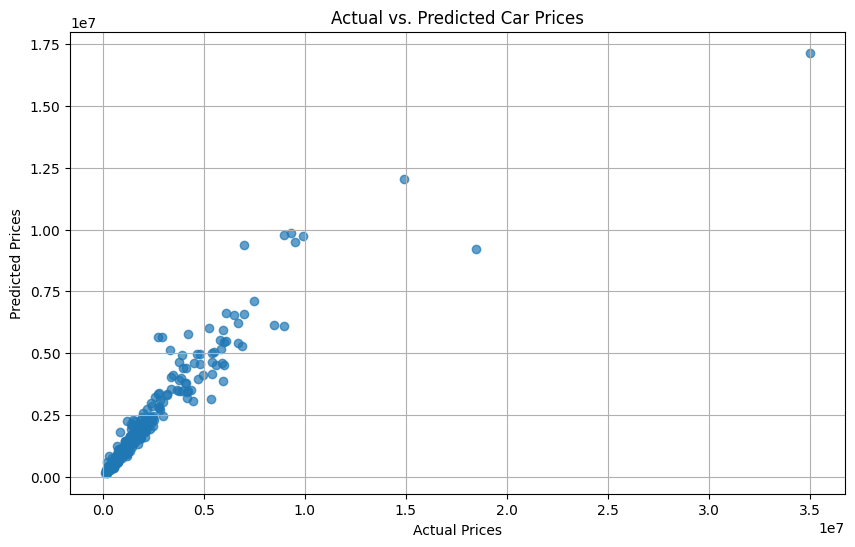


First 10 Actual vs. Predicted Prices:
      Actual Price  Predicted Price
1298       4800000     4.975210e+06
591         825000     8.445600e+05
1318        695000     5.687100e+05
1067        950000     9.596600e+05
29          819999     7.981597e+05
1058        310000     3.818500e+05
712        1000000     8.924233e+05
453        1998999     2.561450e+06
1646        850000     1.821260e+06
757        3950000     4.932300e+06


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.title('Actual vs. Predicted Car Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()

# 2. Create a DataFrame for comparison and display the first 10 rows
comparison_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
print("\nFirst 10 Actual vs. Predicted Prices:")
print(comparison_df.head(10))

## Final Task

### Subtask:
Summarize the model training, evaluation, ONNX conversion, and visualization process. Provide information on how to use the ONNX model for local download or web integration.


## Summary:

### Data Analysis Key Findings

*   A scatter plot visualizing 'Actual vs. Predicted Car Prices' was successfully generated, plotting actual prices on the x-axis and predicted prices on the y-axis to provide a visual assessment of the model's performance.
*   A comparison table (Pandas DataFrame) was created, displaying side-by-side values of actual car prices and their corresponding predicted prices.
*   The first 10 rows of this comparison table were printed, illustrating the model's prediction accuracy for specific examples, such as an `Actual Price` of \$4,800,000 versus a `Predicted Price` of \$4,975,210, and an `Actual Price` of \$825,000 versus a `Predicted Price` of \$844,560.

### Insights or Next Steps

*   **Insight:** The scatter plot allows for a quick visual assessment of the model's linearity and spread of errors. A close alignment of points along a 45-degree line indicates good predictive accuracy. The comparison table offers concrete examples of model performance at an individual prediction level.
*   **Next Step:** Analyze the scatter plot for any systematic biases (e.g., consistent over-prediction or under-prediction for certain price ranges) or outliers to identify areas for model improvement or data preprocessing.
